# E-Commerce User Behavior Analysis

This project explores user behavior in a real-world e-commerce dataset containing over 5 million user interactions. The goal is to analyze the customer journey and uncover patterns that drive conversions — from product views to cart additions and final purchases.

Throughout the analysis, I:
- Clean and preprocess the raw dataset (5GB CSV) to ensure consistency and accuracy
- Perform exploratory data analysis (EDA) to identify trends across time, categories, brands, and prices
- Build a complete **conversion funnel**: `view → cart → purchase`
- Uncover the most profitable time slots and product categories
- Visualize key insights to support decision-making in e-commerce strategies

This project emphasizes real-world data wrangling, storytelling through visualizations, and performance-aware analysis at scale using Python and Pandas.

In [27]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading and Overview

Understand how the dataset is structured and how the data behaves in order to start making informed feature engineering decisions

In [3]:
df = pd.read_csv('data/2019-Nov.csv')
# df = pd.read_csv('data/ecommerce_sample.csv')



In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [5]:
df.describe()

,product_id,category_id,price,user_id
count,6.750198e+07,6.750198e+07,6.750198e+07,6.750198e+07
mean,1.251406e+07,2.057898e+18,2.924593e+02,5.386397e+08
std,1.725741e+07,2.012549e+16,3.556745e+02,2.288516e+07
min,1.000365e+06,2.053014e+18,0.000000e+00,1.030022e+07
25%,1.305977e+06,2.053014e+18,6.924000e+01,5.164762e+08
50%,5.100568e+06,2.053014e+18,1.657700e+02,5.350573e+08
75%,1.730075e+07,2.053014e+18,3.603400e+02,5.610794e+08
max,1.000286e+08,2.187708e+18,2.574070e+03,5.799699e+08


In [6]:
df['event_type'].unique()

array(['view', 'cart', 'purchase'], dtype=object)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 4.5+ GB


In [8]:
df.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    21898171
brand             9224078
price                   0
user_id                 0
user_session           10
dtype: int64

In [9]:
df.duplicated().sum()

100519

## 2. Data Cleaning and Preparation

In [10]:
df['category_code'].fillna('unknown', inplace=True)
df['brand'].fillna('unknown', inplace=True)

C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_16284\2917979788.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['category_code'].fillna('unknown', inplace=True)
C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_16284\2917979788.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [11]:
df.dropna(subset=['user_session'], inplace=True)

In [12]:
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

0

In [15]:
df['brand'] = df['brand'].str.strip().str.lower()
df['category_code'] = df['category_code'].str.strip().str.lower()

<Axes: xlabel='price'>

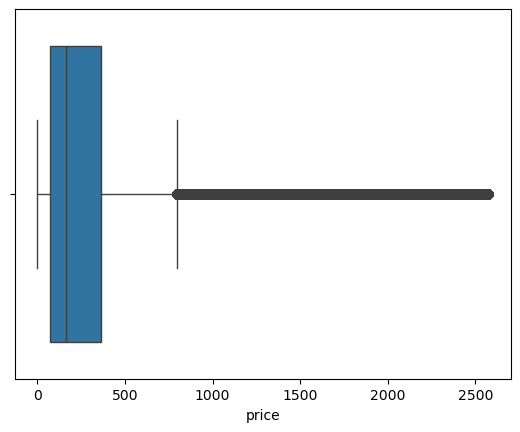

In [16]:
sns.boxplot(x=df['price'])

<Axes: xlabel='price'>

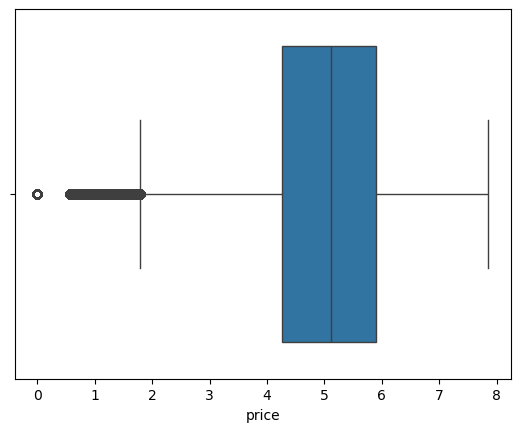

In [17]:
sns.boxplot(x=np.log1p(df['price']))

In [18]:
df['price_log'] = np.log1p(df['price'])

In [19]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [20]:
df['hour'] = df['event_time'].dt.hour
df['weekday'] = df['event_time'].dt.dayofweek
df['month'] = df['event_time'].dt.month

In [21]:
df['is_view'] = (df['event_type'] == 'view').astype(int)
df['is_cart'] = (df['event_type'] == 'cart').astype(int)
df['is_purchase'] = (df['event_type'] == 'purchase').astype(int)

In [ ]:
df.drop(columns=['category_id','product_id','event_type'], inplace=True)

## 3. Exploratory Data Analysis (EDA)

In [25]:
event_totals = {
    'view': df['is_view'].sum(),
    'cart': df['is_cart'].sum(),
    'purchase': df['is_purchase'].sum()
}

event_df = pd.DataFrame(list(event_totals.items()), columns=['event_type', 'count'])

### Events Analysis By Type

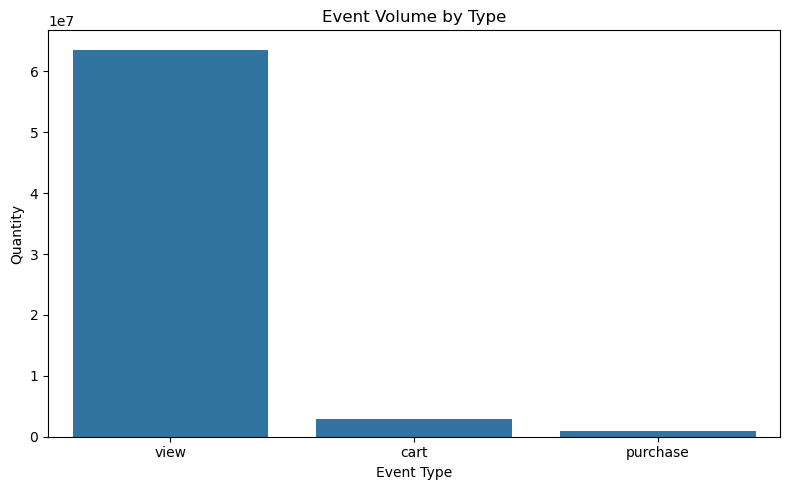

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(data=event_df, x='event_type', y='count')
plt.title('Event Volume by Type')
plt.xlabel('Event Type')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()
